### Import statements

In [57]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.formula.api import ols
import pandas as pd
from datetime import datetime

## Sensor calibration

### Subcritical sensor calibration curve

b0 = 36.867167582476284
b1 = 2.2729171352478246


Text(0, 0.5, 'Water level (cm)')

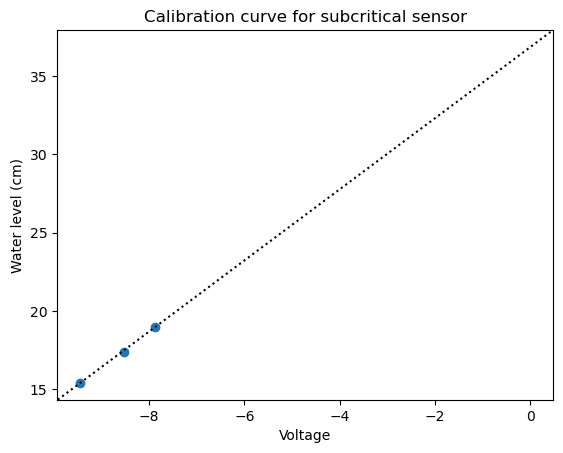

In [58]:
# calibration data
sub_voltage = np.array([-9.4592, -8.5297, -7.8816])
sub_height = np.array([15.4, 17.4, 19])                     # cm
sub_df = pd.DataFrame({'Voltage':sub_voltage, 'Height':sub_height})

# linear fit
sub_calibration = ols('Height ~ Voltage', data=sub_df).fit()
sub_b0, sub_b1 = sub_calibration.params
print(f'b0 = {sub_b0}')
print(f'b1 = {sub_b1}')

# plot
plt.scatter(sub_voltage, sub_height)
plt.axline(xy1=(0,sub_b0), slope=sub_b1, color='black', linestyle=':')
plt.title('Calibration curve for subcritical sensor')
plt.xlabel('Voltage')
plt.ylabel('Water level (cm)')

### Supercritical sensor calibration curve

b0 = 28.6137223023922
b1 = 2.2998132138163467


Text(0, 0.5, 'Water level (cm)')

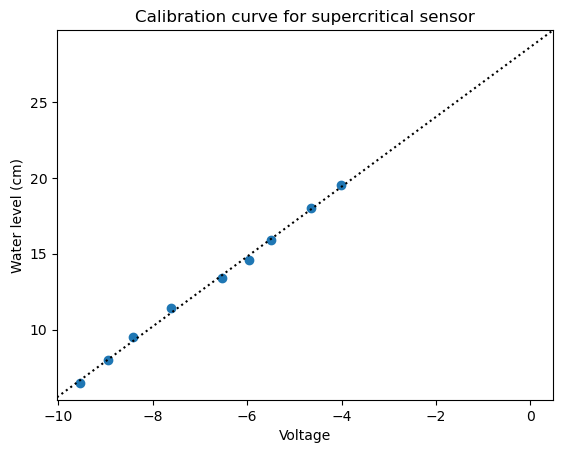

In [59]:
# calibration data
super_voltage = np.array([-9.5491, -8.9420, -8.4136, -7.6184, -6.5391, -5.9702, -5.4983, -4.6409, -4.0175])
super_height = np.array([6.5, 8, 9.5, 11.4, 13.4, 14.6, 15.9, 18, 19.5])    # cm
super_df = pd.DataFrame({'Voltage':super_voltage, 'Height':super_height})

# linear fit
super_calibration = ols('Height ~ Voltage', data=super_df).fit()
super_b0, super_b1 = super_calibration.params
print(f'b0 = {super_b0}')
print(f'b1 = {super_b1}')

# plot
plt.scatter(super_voltage, super_height)
plt.axline(xy1=(0,super_b0), slope=super_b1, color='black', linestyle=':')
plt.title('Calibration curve for supercritical sensor')
plt.xlabel('Voltage')
plt.ylabel('Water level (cm)')

### Head tank sensor calibration curve

b0 = 50.484996799317166
b1 = 2.0198975781500037


Text(0, 0.5, 'Water level (cm)')

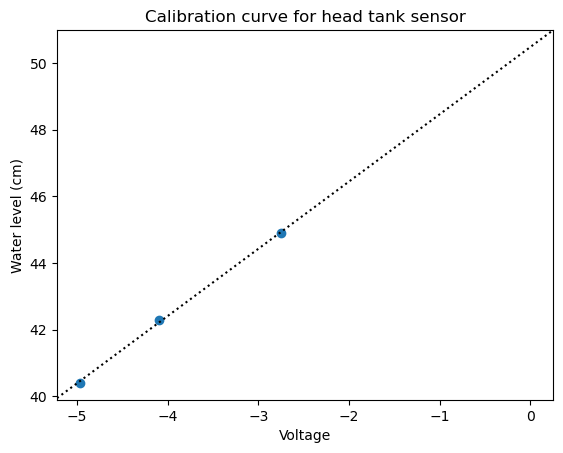

In [60]:
# calibration data
head_voltage = np.array([-2.75, -4.09, -4.97])
head_distance = np.array([9.6, 12.2, 14.1])    # cm, sensor distance from water surface
head_df = pd.DataFrame({'Voltage':head_voltage, 'Distance':head_distance})

# convert distance from water surface to water level
dist_bottom_to_vernier = 143.4 # cm
vernier_reading = 0 # ADD VERNIER READING TO WHATEVER OLS SPITS OUT FOR AN ACCURATE INTERCEPT
#vernier_reading = 0.452*30.48 # ft to cm THIS WILL BE MODIFIED THROUGHOUT EXPERIMENT SO WATCH THIS WHEN PROCESSING DATA
length_vernier = 88.9 # cm

head_df['Height'] = dist_bottom_to_vernier - (length_vernier - vernier_reading) - head_df['Distance']

# linear fit
head_calibration = ols('Height ~ Voltage', data=head_df).fit()
head_b0, head_b1 = head_calibration.params
print(f'b0 = {head_b0}')
print(f'b1 = {head_b1}')

# plot
plt.scatter(head_df['Voltage'], head_df['Height'])
plt.axline(xy1=(0,head_b0), slope=head_b1, color='black', linestyle=':')
plt.title('Calibration curve for head tank sensor')
plt.xlabel('Voltage')
plt.ylabel('Water level (cm)')

#### CALCULATIONS DURING EXPERIMENT

In [61]:
voltage_subcritical = -4.7657
voltage_head = -6.7698

height_subcritical = sub_b0 + sub_b1 * voltage_subcritical
height_head = head_b0 + head_b1 * voltage_head

head_diff = height_head - height_subcritical
print(f'Subcritical height is {height_subcritical:0.2f} cm')
print(f'Head tank height is {height_head:0.2f} cm')
print(f'Head difference is {head_diff:0.2f} cm')

Subcritical height is 26.04 cm
Head tank height is 36.81 cm
Head difference is 10.78 cm


## Load data

### Read venturi meter csv file

In [62]:
# load both dfs and stack them
venturi_file = '11-20-2025-b.csv'
venturi_df = pd.read_csv(venturi_file, sep=';')
venturi_df = venturi_df.drop(['State PV', 'State SV', 'State TV', 'QV', 'State QV', 'Current [mA] ', 'State Current'], axis=1)
venturi_df['PV [in H2O] '] = venturi_df['PV [in H2O] '].str.replace(',', '.')
venturi_df['SV [C] '] = venturi_df['SV [C] '].str.replace(',', '.')
venturi_df['TV'] = venturi_df['TV'].str.replace(',', '.')
venturi_df['Time stamp'] = pd.to_datetime(venturi_df['Time stamp'], format='%d.%m.%Y %H:%M:%S')

venturi_2 = '11-20-2025-c.csv'
venturi_df2 = pd.read_csv(venturi_2, sep=';')
venturi_df2 = venturi_df2.drop(['State PV', 'State SV', 'State TV', 'QV', 'State QV', 'Current [mA] ', 'State Current'], axis=1)
venturi_df2['PV [in H2O] '] = venturi_df2['PV [in H2O] '].str.replace(',', '.')
venturi_df2['SV [C] '] = venturi_df2['SV [C] '].str.replace(',', '.')
venturi_df2['TV'] = venturi_df2['TV'].str.replace(',', '.')
venturi_df2['Time stamp'] = pd.to_datetime(venturi_df2['Time stamp'], format='%d.%m.%Y %H:%M:%S')

# stack dfs
stacked_venturis = pd.concat([venturi_df, venturi_df2], ignore_index=True)

display(stacked_venturis)

,Time stamp,PV [in H2O],SV [C],TV
0,2025-11-20 21:00:29,73.539176940918,20.6014099121094,0.29415687918663
1,2025-11-20 21:00:55,73.2896118164063,20.6036376953125,0.293158501386642
2,2025-11-20 21:01:00,72.1221542358398,20.60400390625,0.28848871588707
3,2025-11-20 21:01:03,73.1549530029297,20.6044006347656,0.292619854211807
4,2025-11-20 21:01:08,72.790168762207,20.6044006347656,0.291160672903061
...,...,...,...,...
930,2025-11-20 22:37:16,0.0265987366437912,20.8369140625,0.000106394945760258
931,2025-11-20 22:37:18,0.0286647826433182,20.8369140625,0.000114659145765472
932,2025-11-20 22:37:21,0.028272395953536,20.8370666503906,0.000113089605292771
933,2025-11-20 22:37:23,0.0277369059622288,20.8372802734375,0.000110947636130732


### Read ADV data file

In [63]:
# from datetime import datetime

# adv_file = 'hre_adv20251114101722.dat'
# adv_data = pd.read_csv(adv_file, sep='\s+', header=None)
# start_time = datetime(2025, 11, 7, 10, 25, 48)
# end_time = datetime(2025, 11, 7, 11, 50, 5)

# time_diff = (end_time - start_time).total_seconds()

# freq = 20 # Hz

# display(adv_data)

### Read height sensor csv files

In [64]:
import glob

csv_files = sorted(glob.glob('*sensor_data.csv'))
dfs = []

for file_name in csv_files:
    try:
        df = pd.read_csv(file_name)
        dfs.append(df)
        print(f"Successfully read: {file_name}")
    except Exception as e:
        print(f"Error reading {file_name}: {e}")

V_ai0 = np.empty(len(csv_files))
V_ai1 = np.empty(len(csv_files))
V_ai2 = np.empty(len(csv_files))

for i, df in enumerate(dfs):
    V_ai0[i] = df['V_ai0'].mean()
    V_ai1[i] = df['V_ai1'].mean()
    V_ai2[i] = df['V_ai2'].mean()

sensor_data = pd.DataFrame({'V_ai0': V_ai0, 'V_ai1': V_ai1, 'V_ai2': V_ai2}) # note that trial indices are one less than the ones I wrote in the notebook
sensor_data['Vernier'] = [0.11,0.11,0.11,0.11,0.11,0.11,0.11,0.11,0.11,0.11,0.46,0.46,0.262,0.262,0.262,0.262,0.262,0.262,0.262]
sensor_data['Filenames'] = csv_files

Successfully read: 2025-11-20_20-37-23_sensor_data.csv
Successfully read: 2025-11-20_20-48-19_sensor_data.csv
Successfully read: 2025-11-20_20-51-09_sensor_data.csv
Successfully read: 2025-11-20_20-54-51_sensor_data.csv
Successfully read: 2025-11-20_21-08-16_sensor_data.csv
Successfully read: 2025-11-20_21-13-06_sensor_data.csv
Successfully read: 2025-11-20_21-19-14_sensor_data.csv
Successfully read: 2025-11-20_21-23-09_sensor_data.csv
Successfully read: 2025-11-20_21-28-12_sensor_data.csv
Successfully read: 2025-11-20_21-33-26_sensor_data.csv
Successfully read: 2025-11-20_21-38-46_sensor_data.csv
Successfully read: 2025-11-20_21-43-17_sensor_data.csv
Successfully read: 2025-11-20_21-51-00_sensor_data.csv
Successfully read: 2025-11-20_21-58-42_sensor_data.csv
Successfully read: 2025-11-20_22-01-09_sensor_data.csv
Successfully read: 2025-11-20_22-05-32_sensor_data.csv
Successfully read: 2025-11-20_22-08-19_sensor_data.csv
Successfully read: 2025-11-20_22-29-20_sensor_data.csv
Successful

### Convert voltages to water heights

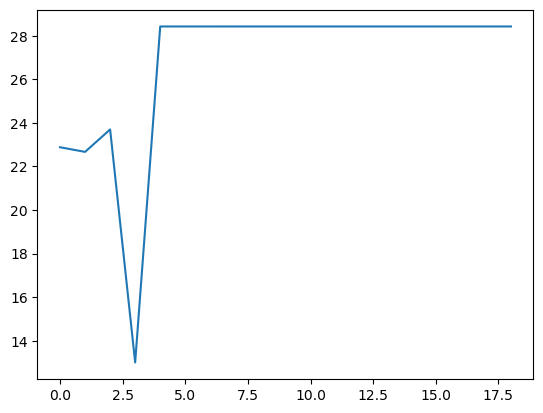

In [65]:
sensor_data['Supercritical Height (cm)'] = super_b0 + super_b1 * sensor_data['V_ai1'] # DOUBLE CHECK IF YOU MATCHED THESE CORRECTLY

plt.plot(sensor_data['Supercritical Height (cm)'])


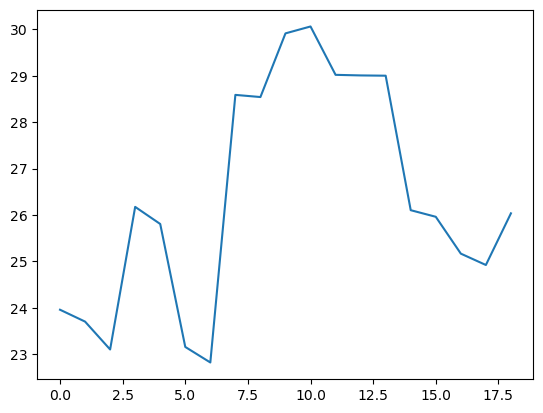

In [66]:
sensor_data['Subcritical Height (cm)'] = sub_b0 + sub_b1 * sensor_data['V_ai0']

plt.plot(sensor_data['Subcritical Height (cm)'])

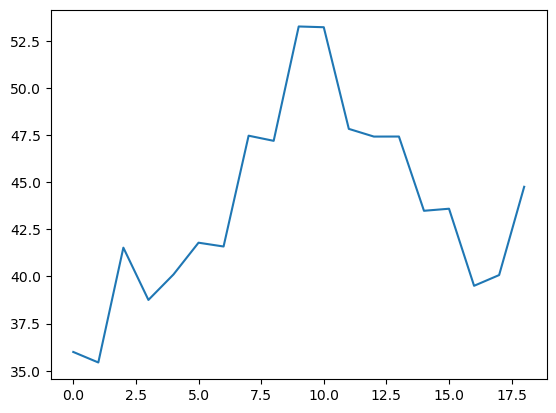

In [67]:
sensor_data['Head Tank Height (cm)'] = head_b0 + sensor_data['Vernier']*30.48 + head_b1 * sensor_data['V_ai2']

plt.plot(sensor_data['Head Tank Height (cm)'])

### Plot the curves together

Text(0, 0.5, 'Water level (cm)')

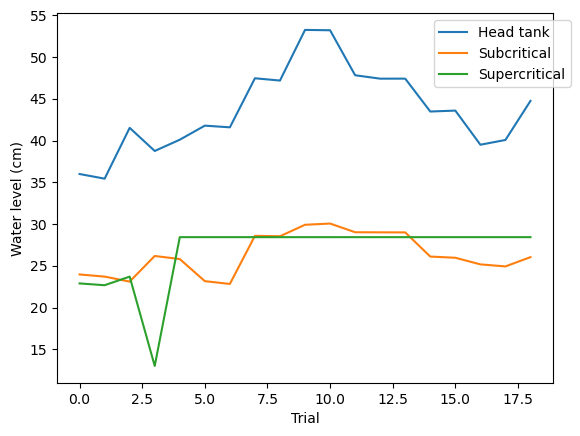

In [68]:
plt.plot(sensor_data['Head Tank Height (cm)'])
plt.plot(sensor_data['Subcritical Height (cm)'])
plt.plot(sensor_data['Supercritical Height (cm)'])


plt.legend(['Head tank', 'Subcritical', 'Supercritical'], bbox_to_anchor=(1.05, 1))
plt.xlabel('Trial')
plt.ylabel('Water level (cm)')

## Stage discharge curve

### Calculate discharge

In [69]:
# Process PV values from venturi meter to match sensor_data trials
from datetime import timedelta

# First, parse the venturi data timestamps
stacked_venturis['datetime'] = pd.to_datetime(stacked_venturis['Time stamp'], format='%d.%m.%Y %H:%M:%S')

# Replace comma with period for PV values (European decimal format)
stacked_venturis['PV [in H2O] '] = stacked_venturis['PV [in H2O] '].astype(str).str.replace(',', '.').astype(float)

# Extract timestamps from sensor_data file names and calculate average PV for each trial
pv_averages = []

for i, file_name in enumerate(csv_files):
    # Extract timestamp from filename (format: YYYY-MM-DD_HH-MM-SS_sensor_data.csv)
    # The timestamp is the end time of the trial
    timestamp_str = file_name.split('_sensor_data.csv')[0]
    end_time = pd.to_datetime(timestamp_str, format='%Y-%m-%d_%H-%M-%S')
    start_time = end_time - timedelta(seconds=30)
    
    # Filter venturi data for this time window
    venturi_subset = stacked_venturis[(stacked_venturis['datetime'] >= start_time) & (stacked_venturis['datetime'] <= end_time)]
    
    # Calculate average PV
    if len(venturi_subset) > 0:
        avg_pv = venturi_subset['PV [in H2O] '].mean()
    else:
        avg_pv = np.nan  # No data in this time window
    
    pv_averages.append(avg_pv)
    print(f"Trial {i}: {file_name}")
    print(f"  Time window: {start_time} to {end_time}")
    print(f"  Average PV: {avg_pv:.6f} in H2O")
    print()

# Add average PV values to sensor_data dataframe
sensor_data['Average PV (in H2O)'] = pv_averages
sensor_data = sensor_data.dropna()

Trial 0: 2025-11-20_20-37-23_sensor_data.csv
  Time window: 2025-11-20 20:36:53 to 2025-11-20 20:37:23
  Average PV: nan in H2O

Trial 1: 2025-11-20_20-48-19_sensor_data.csv
  Time window: 2025-11-20 20:47:49 to 2025-11-20 20:48:19
  Average PV: nan in H2O

Trial 2: 2025-11-20_20-51-09_sensor_data.csv
  Time window: 2025-11-20 20:50:39 to 2025-11-20 20:51:09
  Average PV: nan in H2O

Trial 3: 2025-11-20_20-54-51_sensor_data.csv
  Time window: 2025-11-20 20:54:21 to 2025-11-20 20:54:51
  Average PV: nan in H2O

Trial 4: 2025-11-20_21-08-16_sensor_data.csv
  Time window: 2025-11-20 21:07:46 to 2025-11-20 21:08:16
  Average PV: 73.738214 in H2O

Trial 5: 2025-11-20_21-13-06_sensor_data.csv
  Time window: 2025-11-20 21:12:36 to 2025-11-20 21:13:06
  Average PV: 54.389909 in H2O

Trial 6: 2025-11-20_21-19-14_sensor_data.csv
  Time window: 2025-11-20 21:18:44 to 2025-11-20 21:19:14
  Average PV: 54.139065 in H2O

Trial 7: 2025-11-20_21-23-09_sensor_data.csv
  Time window: 2025-11-20 21:22:39

In [70]:
sensor_data['Discharge (m^3/s)'] = 0.1753*(sensor_data['Average PV (in H2O)']/75.36)**(1/2)

### Calculate head difference

In [71]:
sensor_data['Head diff (cm)'] = sensor_data['Head Tank Height (cm)'] - sensor_data['Subcritical Height (cm)']
display(sensor_data)

,V_ai0,V_ai1,V_ai2,Vernier,Filenames,Supercritical Height (cm),Subcritical Height (cm),Head Tank Height (cm),Average PV (in H2O),Discharge (m^3/s),Head diff (cm)
4,-4.866572,-0.080150,-6.798739,0.110,2025-11-20_21-08-16_sensor_data.csv,28.429392,25.805854,40.105040,73.738214,0.173403,14.299186
5,-6.031808,-0.080183,-5.964389,0.110,2025-11-20_21-13-06_sensor_data.csv,28.429316,23.157367,41.790341,54.389909,0.148926,18.632974
6,-6.179111,-0.080175,-6.064340,0.110,2025-11-20_21-19-14_sensor_data.csv,28.429334,22.822560,41.588450,54.139065,0.148582,18.765890
7,-3.643106,-0.080286,-3.154492,0.110,2025-11-20_21-23-09_sensor_data.csv,28.429079,28.586689,47.466045,96.019217,0.197875,18.879356
8,-3.663572,-0.080275,-3.289638,0.110,2025-11-20_21-28-12_sensor_data.csv,28.429105,28.540173,47.193065,96.379996,0.198246,18.652892
9,-3.060178,-0.080328,-0.286552,0.110,2025-11-20_21-33-26_sensor_data.csv,28.428983,29.911636,53.258990,110.331306,0.212110,23.347354
10,-2.994778,-0.080256,-5.587707,0.460,2025-11-20_21-38-46_sensor_data.csv,28.429150,30.060285,53.219201,111.482753,0.213214,23.158915
11,-3.453125,-0.080235,-8.256917,0.460,2025-11-20_21-43-17_sensor_data.csv,28.429197,29.018500,47.827669,96.283172,0.198147,18.809169
12,-3.458660,-0.080250,-5.471349,0.262,2025-11-20_21-51-00_sensor_data.csv,28.429161,29.005920,47.419192,96.439751,0.198308,18.413272
17,-5.255255,-0.080150,-9.107965,0.262,2025-11-20_22-29-20_sensor_data.csv,28.429393,24.922408,40.073601,54.682936,0.149327,15.151193


### Graph stage vs discharge 

In [72]:
import seaborn as sns

Text(0.5, 1.0, 'Stage discharge curve')

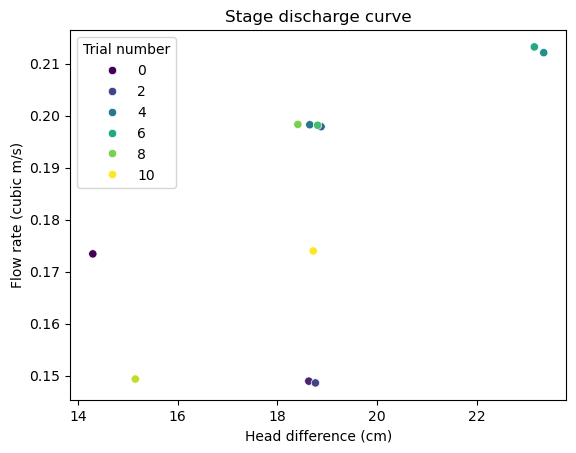

In [74]:
sns.scatterplot(x='Head diff (cm)', y='Discharge (m^3/s)', hue=np.arange(0, len(sensor_data)), data=sensor_data, palette='viridis')

# for i in range(len(sensor_data)):
#     plt.text(sensor_data['Head diff (cm)'][i], sensor_data['Discharge (m^3/s)'][i], i)
#plt.plot(sensor_data['Head diff (cm)'], sensor_data['Discharge (m^3/s)'], color='black', linestyle=':')
#sns.lineplot(x='Head diff (cm)', y='Delta P', data=sensor_data)
plt.xlabel('Head difference (cm)')
plt.ylabel('Flow rate (cubic m/s)')
plt.legend(title='Trial number')
plt.title('Stage discharge curve')

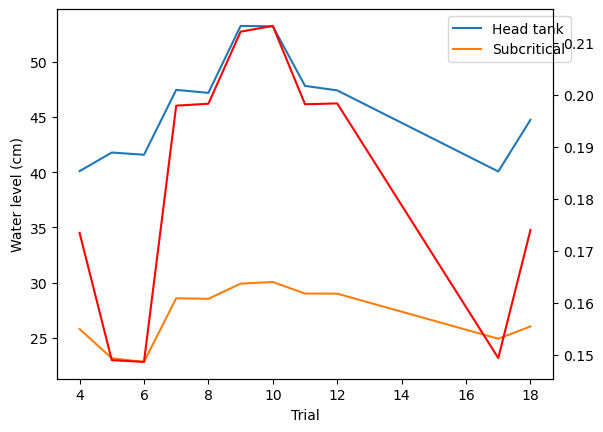

In [75]:
fig, ax1 = plt.subplots()

ax1.plot(sensor_data['Head Tank Height (cm)'])
ax1.plot(sensor_data['Subcritical Height (cm)'])
plt.legend(['Head tank', 'Subcritical', 'Supercritical'], bbox_to_anchor=(1.05, 1))
plt.xlabel('Trial')
plt.ylabel('Water level (cm)')
#plt.plot(sensor_data['Supercritical Height (cm)'])

ax2 = ax1.twinx()
ax2.plot(sensor_data['Discharge (m^3/s)'], color='red')

## Calculate Re, Fr, head loss, etc

In [76]:
def calc_head_loss(sub, super):
    return ((sub - super)**3)/(4*sub*super)

sensor_data['Head loss (cm)'] = calc_head_loss(sensor_data['Subcritical Height (cm)'], sensor_data['Supercritical Height (cm)'])

display(sensor_data)

,V_ai0,V_ai1,V_ai2,Vernier,Filenames,Supercritical Height (cm),Subcritical Height (cm),Head Tank Height (cm),Average PV (in H2O),Discharge (m^3/s),Head diff (cm),Head loss (cm)
4,-4.866572,-0.080150,-6.798739,0.110,2025-11-20_21-08-16_sensor_data.csv,28.429392,25.805854,40.105040,73.738214,0.173403,14.299186,-6.153416e-03
5,-6.031808,-0.080183,-5.964389,0.110,2025-11-20_21-13-06_sensor_data.csv,28.429316,23.157367,41.790341,54.389909,0.148926,18.632974,-5.564137e-02
6,-6.179111,-0.080175,-6.064340,0.110,2025-11-20_21-19-14_sensor_data.csv,28.429334,22.822560,41.588450,54.139065,0.148582,18.765890,-6.791225e-02
7,-3.643106,-0.080286,-3.154492,0.110,2025-11-20_21-23-09_sensor_data.csv,28.429079,28.586689,47.466045,96.019217,0.197875,18.879356,1.204385e-06
8,-3.663572,-0.080275,-3.289638,0.110,2025-11-20_21-28-12_sensor_data.csv,28.429105,28.540173,47.193065,96.379996,0.198246,18.652892,4.221678e-07
9,-3.060178,-0.080328,-0.286552,0.110,2025-11-20_21-33-26_sensor_data.csv,28.428983,29.911636,53.258990,110.331306,0.212110,23.347354,9.582028e-04
10,-2.994778,-0.080256,-5.587707,0.460,2025-11-20_21-38-46_sensor_data.csv,28.429150,30.060285,53.219201,111.482753,0.213214,23.158915,1.269560e-03
11,-3.453125,-0.080235,-8.256917,0.460,2025-11-20_21-43-17_sensor_data.csv,28.429197,29.018500,47.827669,96.283172,0.198147,18.809169,6.201799e-05
12,-3.458660,-0.080250,-5.471349,0.262,2025-11-20_21-51-00_sensor_data.csv,28.429161,29.005920,47.419192,96.439751,0.198308,18.413272,5.816638e-05
17,-5.255255,-0.080150,-9.107965,0.262,2025-11-20_22-29-20_sensor_data.csv,28.429393,24.922408,40.073601,54.682936,0.149327,15.151193,-1.521893e-02
